# **Predicción del Rendimiento Académico mediante un Perceptrón Multicapa (MLP)**

### **Información general**

**Asignatura:** Aprendizaje Profundo  
**Actividad:** Correcciones Notebook Semana 1 - Fundamentos de Redes Neuronales  
**Fecha:** 05 julio de 2026  
**Dataset:** Student Performance Dataset  
**Fuente:** Kaggle  
**Autores:**  
- Calero López Gerardo Paúl  
- Vásconez Pozo David Rubén  
- Viteri Ayala Flavia Kamila  

### **Objetivo del proyecto**

El objetivo de este notebook es implementar un modelo de Perceptrón Multicapa (MLP) para predecir el rendimiento académico de un estudiante a partir de variables relacionadas con hábitos de estudio, antecedentes académicos y actividades complementarias.

La variable objetivo del modelo es `Performance Index`, la cual representa el nivel de desempeño académico alcanzado por cada estudiante. Debido a que esta variable es numérica y continua, el problema se aborda mediante una tarea de **regresión supervisada**.

### **Pregunta de análisis**

¿Qué factores académicos y hábitos de estudio permiten explicar o predecir el rendimiento académico de un estudiante?  

### **Preguntas secundarias**
- ¿Las calificaciones previas son el principal predictor del rendimiento académico?  
- ¿Estudiar más horas se asocia con un mejor desempeño?  
- ¿Las horas de sueño influyen en el rendimiento académico?  
- ¿Las actividades extracurriculares tienen impacto sobre el desempeño estudiantil?  
- ¿La práctica de exámenes o cuestionarios contribuye a mejorar los resultados académicos?  

### **Justificación del problema**

El rendimiento académico es un tema de interés en el ámbito educativo debido a su relación con el aprendizaje, la permanencia estudiantil y el logro de objetivos formativos. Comprender los factores que influyen en el desempeño de los estudiantes permite identificar hábitos y características que favorecen mejores resultados académicos.

El conjunto de datos seleccionado contiene variables numéricas y categóricas relacionadas con el proceso de aprendizaje, por lo que resulta adecuado para aplicar técnicas de aprendizaje profundo. En particular, un Perceptrón Multicapa permite modelar relaciones lineales y no lineales entre las variables predictoras y el rendimiento académico, facilitando la construcción de modelos predictivos capaces de estimar el desempeño de nuevos estudiantes.

### **Aportes adicionales**

Se realiza un **experimento de ajuste de hiperparámetros** en el que se modifica la tasa de aprendizaje, el tamaño de lote, el número de épocas, la tasa de dropout y la arquitectura de la red, con el fin de comparar cuantitativamente los resultados frente al modelo original mediante métricas de regresión y gráficos de comparación directa.

### **Descripción general del enfoque**

En este notebook se desarrolla el flujo completo de trabajo para un modelo MLP:

1. Carga y exploración inicial del dataset.
2. Análisis exploratorio de datos (EDA).
3. Limpieza y preprocesamiento de datos.
4. División del dataset en entrenamiento y prueba.
5. Construcción del modelo MLP para regresión.
6. Entrenamiento del Modelo Base.
7. Técnica de Mejora — Comparación Adam vs SGD.
8. Evaluación del modelo con métricas de regresión.
9. Visualización e interpretación de resultados.

**9b. Experimento con nuevos hiperparámetros — comparación de resultados.**

10. Respuesta a preguntas secundarias.
11. Resumen final y conclusiones.
12. Exportación de resultados para informe Quarto.

---
## **Sección 0: Configuraciones preliminares**

In [1]:
# Importación de librerías principales

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Configuración visual básica

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ─── Carpeta de salida para figuras y tablas (usada por el informe Quarto) ────
# Todos los artefactos se guardan aquí; el .qmd los llama por ruta relativa.

OUTPUT_DIR = 'quarto_assets'
FIG_DIR    = os.path.join(OUTPUT_DIR, 'figures')
TAB_DIR    = os.path.join(OUTPUT_DIR, 'tables')

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print(f'Carpeta de salida: {OUTPUT_DIR}/')
print(f'  figuras → {FIG_DIR}/')
print(f'  tablas  → {TAB_DIR}/')

Carpeta de salida: quarto_assets/
  figuras → quarto_assets\figures/
  tablas  → quarto_assets\tables/


---
## **Sección 1: Carga y exploración inicial del dataset**

In [3]:
# Carga del dataset

url = "https://raw.githubusercontent.com/fkviteri/uide-maestria/main/05-deep-learning/Student_Performance.csv"

df = pd.read_csv(
    url,
    engine="python",
    on_bad_lines="skip"
)

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.00
1,4,82,No,4,2,65.00
2,8,51,Yes,7,2,45.00
3,5,52,Yes,5,2,36.00
4,7,75,No,8,5,66.00


In [4]:
# Número de observaciones y variables

filas, columnas = df.shape

print(f"Número de observaciones: {filas}")
print(f"Número de variables:     {columnas}")

Número de observaciones: 10000
Número de variables:     6


In [5]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.99,69.45,6.53,4.58,55.22
std,2.59,17.34,1.70,2.87,19.21
min,1.00,40.00,4.00,0.00,10.00
25%,3.00,54.00,5.00,2.00,40.00
50%,5.00,69.00,7.00,5.00,55.00
75%,7.00,85.00,8.00,7.00,71.00
max,9.00,99.00,9.00,9.00,100.00


In [7]:
# Revisión de valores faltantes

missing_values = pd.DataFrame({
    'Variable': df.columns,
    'Valores Faltantes': df.isnull().sum().values
})

missing_values

,Variable,Valores Faltantes
0,Hours Studied,0
1,Previous Scores,0
2,Extracurricular Activities,0
3,Sleep Hours,0
4,Sample Question Papers Practiced,0
5,Performance Index,0


In [8]:
# Revisión de registros duplicados

duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 127


In [9]:
# Tipo de cada variable

tabla_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.values
})

tabla_tipos

,Variable,Tipo
0,Hours Studied,int64
1,Previous Scores,int64
2,Extracurricular Activities,str
3,Sleep Hours,int64
4,Sample Question Papers Practiced,int64
5,Performance Index,float64


In [10]:
# Conteo de valores únicos

resumen_unicos = pd.DataFrame({
    'Variable': df.columns,
    'Valores_Unicos': [df[col].nunique() for col in df.columns],
    'Contiene_Cero': [
        0 in df[col].dropna().unique()
        if pd.api.types.is_numeric_dtype(df[col])
        else False
        for col in df.columns
    ]
})

resumen_unicos

,Variable,Valores_Unicos,Contiene_Cero
0,Hours Studied,9,False
1,Previous Scores,60,False
2,Extracurricular Activities,2,False
3,Sleep Hours,6,False
4,Sample Question Papers Practiced,10,True
5,Performance Index,91,False


In [11]:
# Verificación de valores únicos por columna

for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"{'='*50}")
    print(sorted(df[col].dropna().unique()))


Columna: Hours Studied
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Columna: Previous Scores
[np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.in

---
## **Sección 2: Análisis Exploratorio de Datos (EDA)**

El análisis exploratorio de datos tiene como objetivo comprender la distribución de las variables, identificar posibles patrones y evaluar la relación entre las características del dataset y el rendimiento académico de los estudiantes.

Esta etapa permitirá obtener una primera aproximación sobre los factores que podrían influir en el desempeño estudiantil antes de construir el modelo de Perceptrón Multicapa (MLP).

In [12]:
# 2.1 Definición de variables

target = 'Performance Index'

features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

categoricas = ['Extracurricular Activities']

numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

tabla_variables = pd.DataFrame({
    'Variable': features + [target],
    'Tipo': ['Numérica', 'Numérica', 'Categórica',
             'Numérica', 'Numérica', 'Numérica'],
    'Rol': ['Predictora'] * len(features) + ['Objetivo']
})

tabla_variables

,Variable,Tipo,Rol
0,Hours Studied,Numérica,Predictora
1,Previous Scores,Numérica,Predictora
2,Extracurricular Activities,Categórica,Predictora
3,Sleep Hours,Numérica,Predictora
4,Sample Question Papers Practiced,Numérica,Predictora
5,Performance Index,Numérica,Objetivo


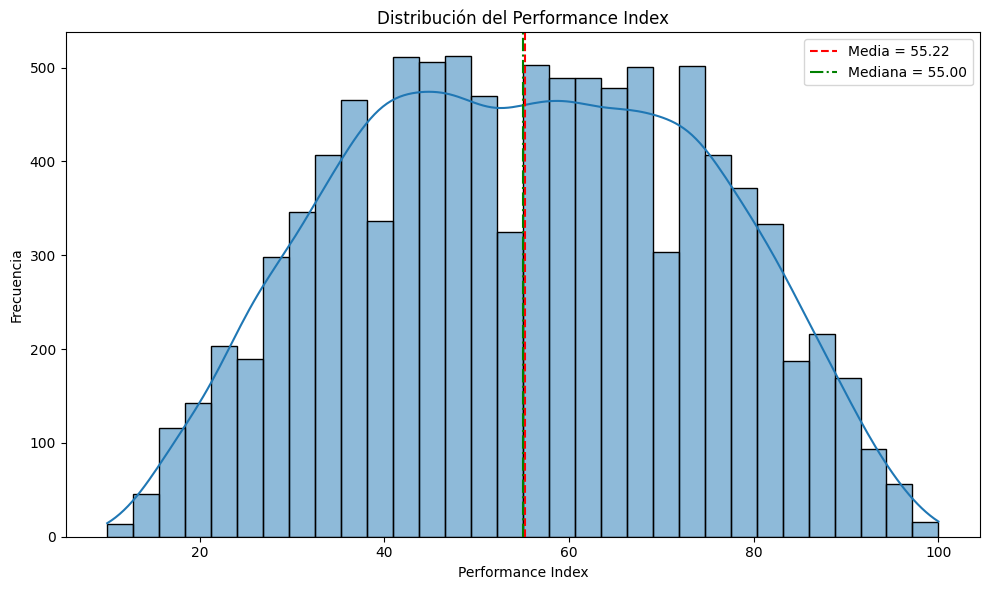

In [13]:
# 2.2.1 Distribución de la variable objetivo

media   = df['Performance Index'].mean()
mediana = df['Performance Index'].median()

plt.figure(figsize=(10, 6))

sns.histplot(df['Performance Index'], kde=True)

plt.axvline(media,   color='red',   linestyle='--', label=f'Media = {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-.', label=f'Mediana = {mediana:.2f}')

plt.title('Distribución del Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_01_dist_target.png', dpi=150, bbox_inches='tight')
plt.show()

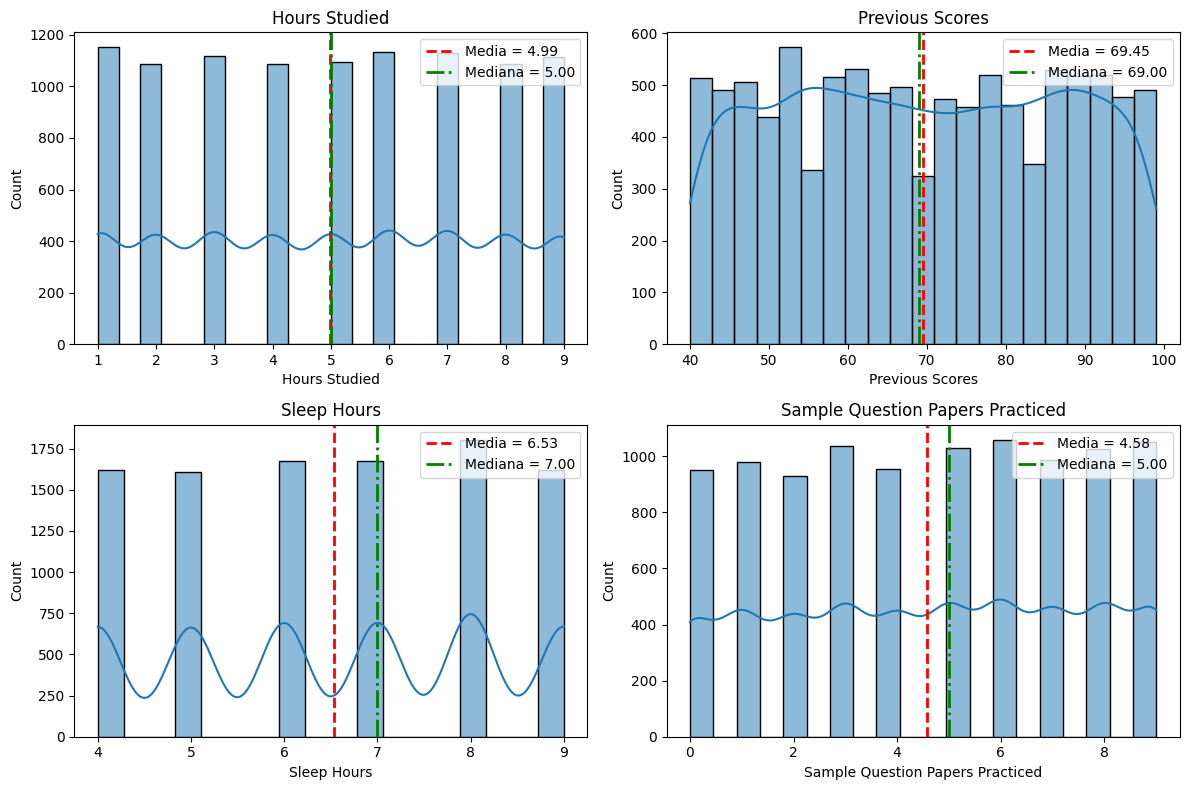

In [14]:
# 2.2.2 Distribución de variables predictoras numéricas

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables_num = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

for ax, var in zip(axes.flatten(), variables_num):

    media   = df[var].mean()
    mediana = df[var].median()

    sns.histplot(df[var], kde=True, ax=ax)

    ax.axvline(media,   color='red',   linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.set_title(var)
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_02_dist_predictoras.png', dpi=150, bbox_inches='tight')
plt.show()

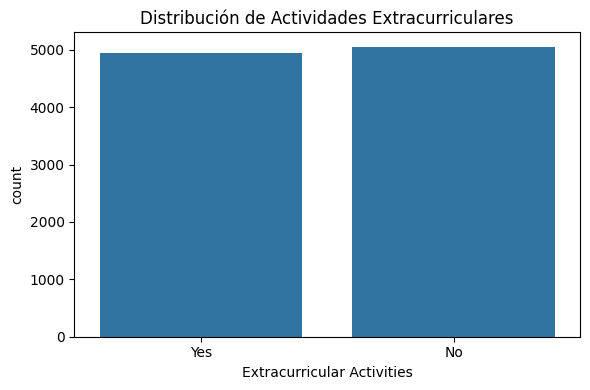

In [15]:
# 2.3.1 Distribución de actividades extracurriculares

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Extracurricular Activities')
plt.title('Distribución de Actividades Extracurriculares')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_03_extracurricular_count.png', dpi=150, bbox_inches='tight')
plt.show()

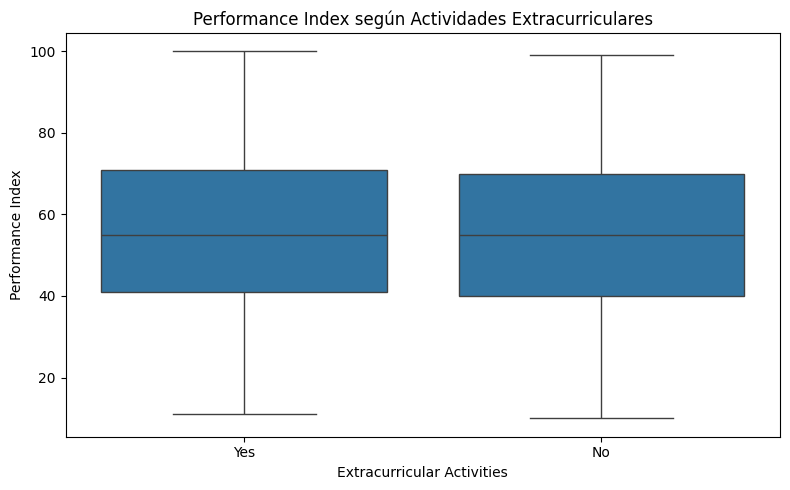

In [16]:
# 2.3.2 Rendimiento según actividades extracurriculares

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Extracurricular Activities', y='Performance Index')
plt.title('Performance Index según Actividades Extracurriculares')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_04_boxplot_extracurricular.png', dpi=150, bbox_inches='tight')
plt.show()

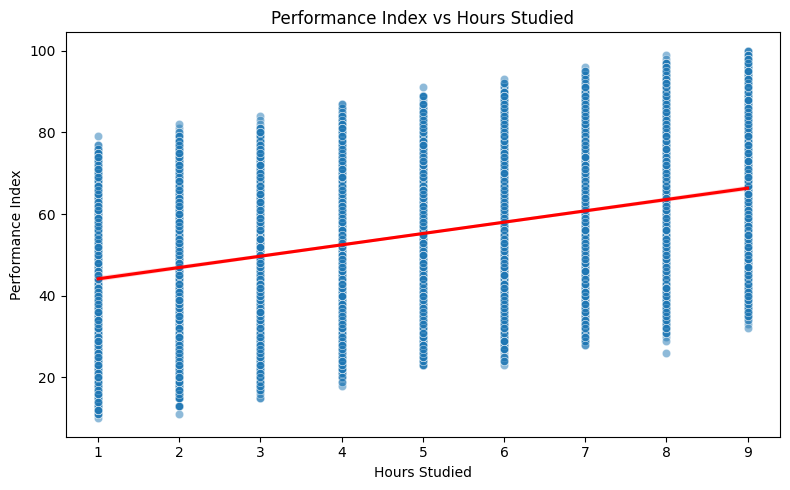

In [17]:
# 2.3.3 Rendimiento vs Horas de estudio

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Hours Studied', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Hours Studied', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Hours Studied')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_05_scatter_horas.png', dpi=150, bbox_inches='tight')
plt.show()

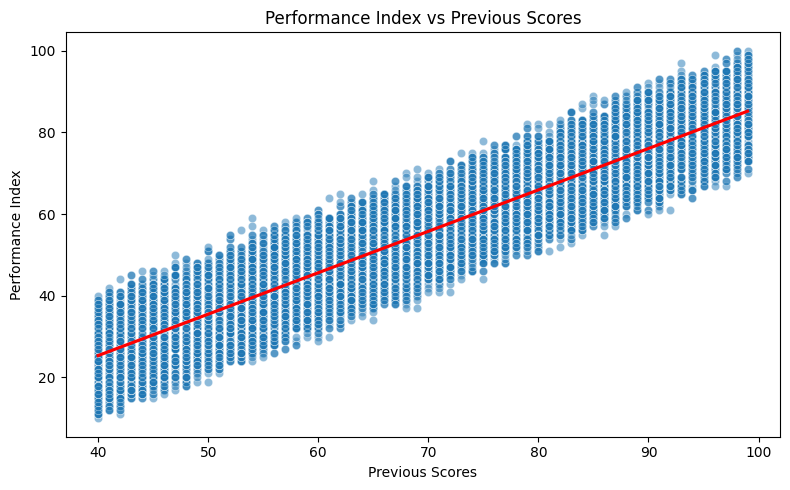

In [18]:
# 2.3.4 Rendimiento vs Calificaciones previas

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Previous Scores', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Previous Scores', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Previous Scores')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_06_scatter_scores.png', dpi=150, bbox_inches='tight')
plt.show()

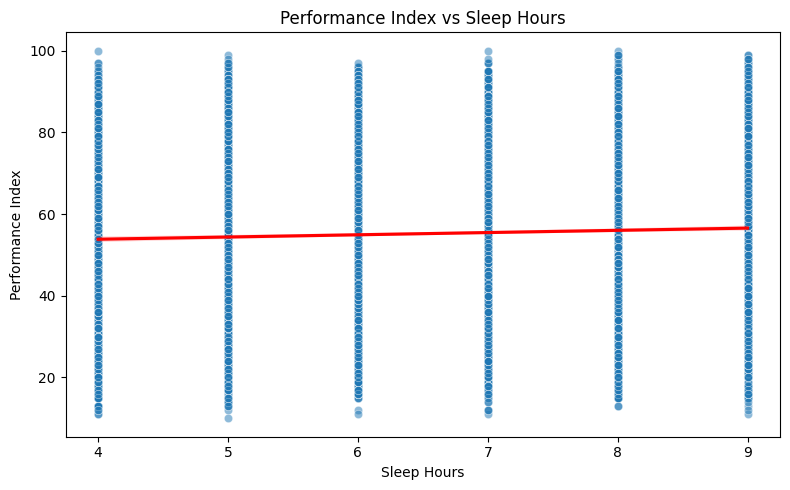

In [19]:
# 2.3.5 Rendimiento vs Horas de sueño

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sleep Hours', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Sleep Hours', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Sleep Hours')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_07_scatter_sueno.png', dpi=150, bbox_inches='tight')
plt.show()

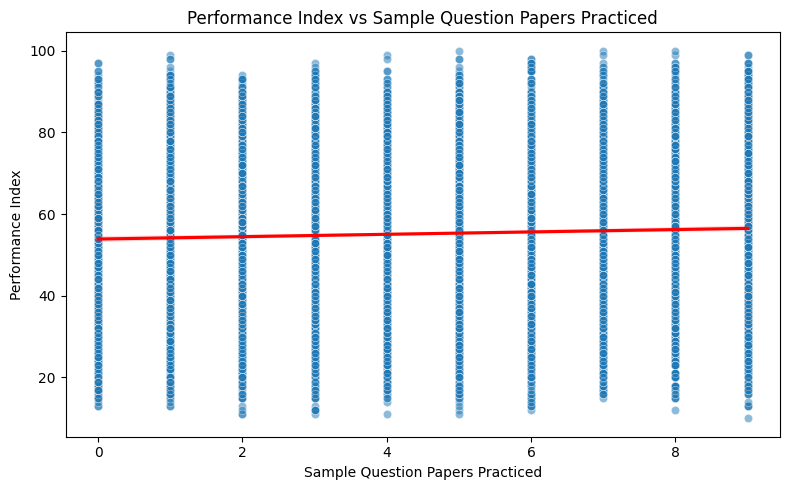

In [20]:
# 2.3.6 Rendimiento vs Exámenes de práctica

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sample Question Papers Practiced', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Sample Question Papers Practiced', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Sample Question Papers Practiced')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_08_scatter_examenes.png', dpi=150, bbox_inches='tight')
plt.show()

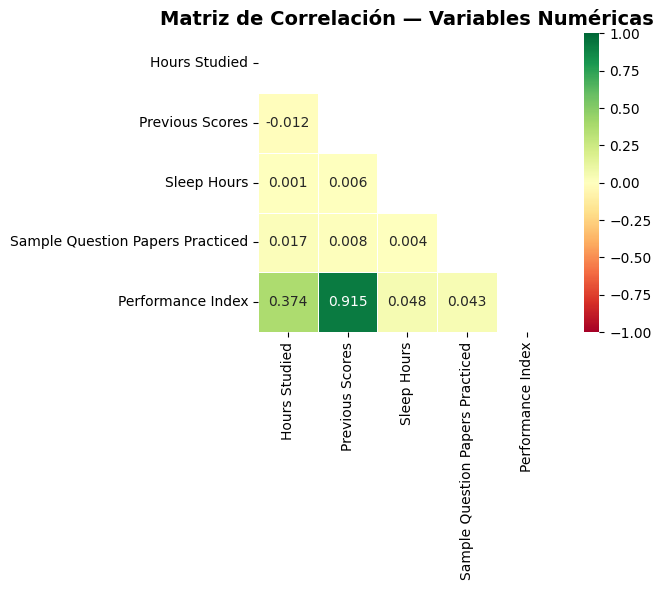

In [21]:
# 2.4 Matriz de correlación

num_cols = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Matriz de Correlación — Variables Numéricas',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_09_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### **2.5 Principales hallazgos y decisiones**

#### **Principales hallazgos:**

- El Performance Index presenta una distribución equilibrada, con media y mediana muy similares.
- Las variables numéricas muestran distribuciones uniformes y sin sesgos importantes.
- La cantidad de estudiantes con y sin actividades extracurriculares es prácticamente la misma.
- No se observan diferencias relevantes en el rendimiento entre estudiantes con y sin actividades extracurriculares.
- Existe una relación positiva entre las horas de estudio y el rendimiento académico.
- Las calificaciones previas muestran una fuerte relación positiva con el rendimiento académico.
- La matriz de correlación confirma que las calificaciones previas son la variable más asociada al rendimiento (r = 0.915).
- Las horas de estudio presentan una relación moderada (r = 0.374).

#### **Principales decisiones para el modelado:**

- Variable objetivo: `Performance Index` (numérica continua → regresión supervisada).
- `Extracurricular Activities` será codificada binarmente (Yes=1, No=0).
- Las variables numéricas serán escaladas con StandardScaler **después** de dividir el dataset para evitar data leakage.
- División 80/20: con ~10,000 registros el 80% garantiza suficientes muestras para que la red neuronal aprenda patrones estables; el 20% es suficiente para una estimación confiable del error de generalización.
- Todas las variables se mantendrán para que el MLP identifique posibles relaciones no lineales.

---
## **Sección 3: Limpieza y preprocesamiento de datos**

In [22]:
# 3.1.1 Verificación de valores faltantes

df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [23]:
# 3.1.2 Verificación y eliminación de registros duplicados

duplicados = df.duplicated().sum()
print(f'Registros duplicados antes: {duplicados}')

df = df.drop_duplicates()
print(f'Nueva dimensión del dataset: {df.shape}')
print(f'Registros duplicados después: {df.duplicated().sum()}')

Registros duplicados antes: 127
Nueva dimensión del dataset: (9873, 6)
Registros duplicados después: 0


In [24]:
# 3.2 Definición de X e y

target = 'Performance Index'

features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

X = df[features].copy()   # <-- .copy() necesario para evitar SettingWithCopyWarning
y = df[target]

In [25]:
# 3.3 Codificación de la variable categórica
# Extracurricular Activities: Yes → 1, No → 0

X['Extracurricular Activities'] = (
    X['Extracurricular Activities']
    .astype(str)
    .str.strip()
    .map({'Yes': 1, 'No': 0})
)

X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


---
## **Sección 4: División del Dataset en Entrenamiento y Prueba**

La división se realiza **antes del escalado** para evitar data leakage: si se escala con toda la muestra, la información estadística del conjunto de prueba (media y desviación estándar) contamina el entrenamiento, inflando artificialmente las métricas. El `StandardScaler` se ajusta (`fit`) únicamente con los datos de entrenamiento y se aplica (`transform`) a ambos conjuntos.

Se utiliza una proporción **80/20**: con ~10,000 registros, el 80% proporciona suficiente variabilidad para entrenar la red neuronal; el 20% (~2,000 registros) es estadísticamente suficiente para estimar el error de generalización con baja varianza.

In [26]:
# 4.1 División entrenamiento-prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('Dimensiones de entrenamiento')
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\nDimensiones de prueba')
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

Dimensiones de entrenamiento
X_train: (7898, 5)
y_train: (7898,)

Dimensiones de prueba
X_test: (1975, 5)
y_test: (1975,)


In [27]:
# Proporción entrenamiento-prueba

total = len(df)

print(f'Total registros: {total}')
print(f'Entrenamiento:   {len(X_train)} ({len(X_train)/total:.1%})')
print(f'Prueba:          {len(X_test)} ({len(X_test)/total:.1%})')

Total registros: 9873
Entrenamiento:   7898 (80.0%)
Prueba:          1975 (20.0%)


In [28]:
# 4.2 Escalado DESPUÉS de dividir
# fit_transform sobre train → transform sobre test

scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[numericas] = scaler.fit_transform(X_train[numericas])
X_test[numericas]  = scaler.transform(X_test[numericas])

print('Escalado aplicado correctamente.')
print('\nMedia de variables numéricas en train (≈ 0):')
print(X_train[numericas].mean().round(4))
print('\nDesviación estándar en train (≈ 1):')
print(X_train[numericas].std().round(4))

Escalado aplicado correctamente.

Media de variables numéricas en train (≈ 0):
Hours Studied                      -0.00
Previous Scores                    -0.00
Sleep Hours                         0.00
Sample Question Papers Practiced   -0.00
dtype: float64

Desviación estándar en train (≈ 1):
Hours Studied                      1.00
Previous Scores                    1.00
Sleep Hours                        1.00
Sample Question Papers Practiced   1.00
dtype: float64


In [29]:
# Verificación de los datos procesados

X_train.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
count,7898.00,7898.00,7898.00,7898.00,7898.00
mean,-0.00,-0.00,0.50,0.00,-0.00
std,1.00,1.00,0.50,1.00,1.00
min,-1.54,-1.70,0.00,-1.50,-1.61
25%,-0.77,-0.89,0.00,-0.91,-0.91
50%,0.00,-0.02,0.00,0.27,0.14
75%,0.78,0.91,1.00,0.86,0.84
max,1.55,1.71,1.00,1.45,1.54


---
## **Sección 5: Construcción del Modelo MLP para Regresión**

Al tratarse de una variable objetivo numérica continua, se utiliza una arquitectura con una neurona de salida sin función de activación y función de pérdida MSE.

### **Justificación de la arquitectura**

| Decisión | Elección | Justificación |
|---|---|---|
| Capas ocultas | 3 (64 → 32 → 16) | Patrón decreciente: cada capa extrae representaciones más abstractas; 3 capas balancea capacidad y tiempo de entrenamiento para 5 features |
| Activación ocultas | ReLU | Evita el problema del gradiente desvaneciente; computacionalmente eficiente; estándar para regresión tabular |
| Dropout | 0.2 en capas 1 y 2 | Regularización para reducir sobreajuste; 20% es conservador dado el tamaño del dataset (~10k registros) |
| Salida | 1 neurona, sin activación | Problema de regresión: la salida debe ser un valor continuo sin restricción de rango |
| Loss | MSE | Penaliza errores grandes; estándar para regresión; diferenciable en todo punto |
| Learning rate | 0.001 | Valor por defecto de Adam; adecuado como punto de partida sin scheduling |

In [30]:
# Función para construir el modelo base (Sección 5 y 6)

def construir_mlp_base(n_features, dropout_rate=0.2, learning_rate=0.001):
    """
    Construye un modelo MLP para regresión.

    Parámetros:
    -----------
    n_features     : número de variables de entrada
    dropout_rate   : fracción de neuronas a desactivar durante entrenamiento
    learning_rate  : tasa de aprendizaje del optimizador

    Retorna:
    --------
    model : modelo Keras compilado
    """

    model = keras.Sequential([

        # Capa de entrada
        layers.Input(shape=(n_features,)),

        # Primera capa oculta: 64 neuronas, ReLU
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),

        # Segunda capa oculta: 32 neuronas, ReLU
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),

        # Tercera capa oculta: 16 neuronas, ReLU
        layers.Dense(16, activation='relu'),

        # Capa de salida: 1 neurona sin activación (regresión)
        layers.Dense(1)

    ], name='MLP_Student_Performance_Base')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model


# Número de variables de entrada
n_features = X_train.shape[1]

# Construcción del modelo base
modelo_base = construir_mlp_base(
    n_features=n_features,
    dropout_rate=0.2,
    learning_rate=0.001
)

# Resumen de la arquitectura
modelo_base.summary()

Model: "MLP_Student_Performance_Base"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼───

---
## **Sección 6: Entrenamiento del Modelo Base**

La red ajusta sus pesos mediante retropropagación del error. Se usa un subconjunto de validación (20% del train) para monitorear el desempeño durante el entrenamiento y detectar posibles problemas de sobreajuste.

In [31]:
# Entrenamiento del modelo base

history_base = modelo_base.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=0       # silencioso para presentación
)

print('Entrenamiento completado.')
print(f"Loss final entrenamiento: {history_base.history['loss'][-1]:.4f}")
print(f"Loss final validación:    {history_base.history['val_loss'][-1]:.4f}")
print(f"MAE final entrenamiento:  {history_base.history['mae'][-1]:.4f}")
print(f"MAE final validación:     {history_base.history['val_mae'][-1]:.4f}")

Entrenamiento completado.
Loss final entrenamiento: 11.1946
Loss final validación:    7.6490
MAE final entrenamiento:  2.5100
MAE final validación:     2.1761


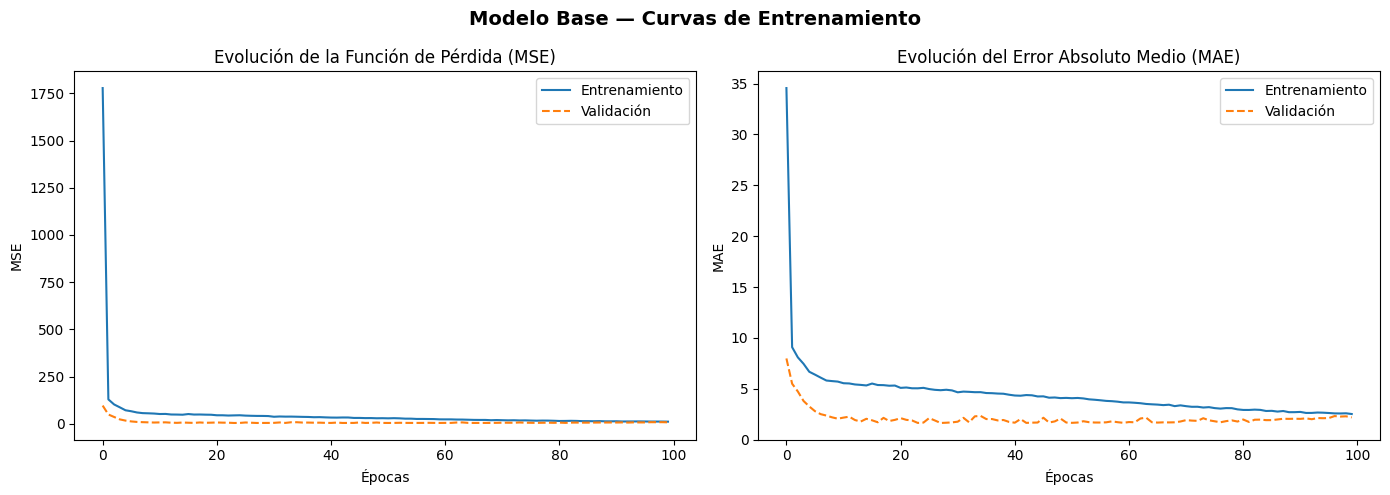

In [32]:
# Evolución de la función de pérdida — Modelo Base

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_base.history['loss'],     label='Entrenamiento')
axes[0].plot(history_base.history['val_loss'], label='Validación', linestyle='--')
axes[0].set_title('Evolución de la Función de Pérdida (MSE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history_base.history['mae'],     label='Entrenamiento')
axes[1].plot(history_base.history['val_mae'], label='Validación', linestyle='--')
axes[1].set_title('Evolución del Error Absoluto Medio (MAE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Modelo Base — Curvas de Entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_10_base_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **Sección 7: Técnica de Mejora — Comparación Adam vs SGD**

Con el objetivo de evaluar el impacto del optimizador sobre el desempeño de la red neuronal, se comparan Adam y SGD usando la misma arquitectura, dataset y parámetros de entrenamiento. La única diferencia es el optimizado, ya que Adam utiliza momentos adaptativos para ajustar la tasa de aprendizaje individual por parámetro, lo que suele explicar su convergencia más suave y directa frente a las oscilaciones características de SGD con momento fijo.

Esta técnica corresponde a la opción **"Solucionador / Optimizador"** del punto 5 de la guía de actividad.

In [33]:
# Función para construir modelos de comparación (optimizador como parámetro)
# NOTA: esta función es distinta a construir_mlp_base y tiene nombre propio
# para evitar sobreescribir la función anterior.

def construir_mlp_comparacion(n_features, optimizer, dropout_rate=0.2):
    """
    Construye un modelo MLP para comparación de optimizadores.

    Parámetros:
    -----------
    n_features     : número de variables de entrada
    optimizer      : instancia de optimizador Keras (Adam, SGD, etc.)
    dropout_rate   : fracción de neuronas a desactivar

    Retorna:
    --------
    model : modelo Keras compilado
    """

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [34]:
# Modelo Adam

modelo_adam = construir_mlp_comparacion(
    n_features=X_train.shape[1],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

history_adam = modelo_adam.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=0
)

print('Adam entrenado.')
print(f"Val loss final: {history_adam.history['val_loss'][-1]:.4f}")
print(f"Val MAE final:  {history_adam.history['val_mae'][-1]:.4f}")

Adam entrenado.
Val loss final: 76.7852
Val MAE final:  7.4366


In [35]:
# Modelo SGD

modelo_sgd = construir_mlp_comparacion(
    n_features=X_train.shape[1],
    optimizer=keras.optimizers.SGD(learning_rate=0.001)
)

history_sgd = modelo_sgd.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=0
)

print('SGD entrenado.')
print(f"Val loss final: {history_sgd.history['val_loss'][-1]:.4f}")
print(f"Val MAE final:  {history_sgd.history['val_mae'][-1]:.4f}")

SGD entrenado.
Val loss final: 15.1884
Val MAE final:  3.0583


In [36]:
# Comparación de métricas finales de validación

comparacion_val = pd.DataFrame({
    'Optimizador': ['Adam', 'SGD'],
    'Loss Validación': [
        history_adam.history['val_loss'][-1],
        history_sgd.history['val_loss'][-1]
    ],
    'MAE Validación': [
        history_adam.history['val_mae'][-1],
        history_sgd.history['val_mae'][-1]
    ]
})

comparacion_val

,Optimizador,Loss Validación,MAE Validación
0,Adam,76.79,7.44
1,SGD,15.19,3.06


---
## **Sección 8: Evaluación del Modelo con Métricas de Regresión**

Se evalúan los modelos sobre el conjunto de prueba (datos no vistos durante entrenamiento) usando las siguientes métricas:

- **MSE**: Promedio de los errores al cuadrado; castiga con fuerza los errores grandes.
- **RMSE**: La raíz del MSE; indica cuántos puntos de nota se falla en la escala original, penalizando los casos extremos.
- **MAE**: El error promedio típico; dice cuánto se equivoca el modelo por estudiante en promedio.
- **$R^2$**: El porcentaje de acierto en variabilidad; un 0.99 significa que el modelo explica el 99% del rendimiento académico.

In [37]:
# 8.1 Predicciones sobre el conjunto de prueba

y_pred_adam = modelo_adam.predict(X_test, verbose=0).flatten()
y_pred_sgd  = modelo_sgd.predict(X_test,  verbose=0).flatten()

In [38]:
# 8.2 Cálculo de métricas de regresión

def calcular_metricas(y_true, y_pred, nombre_modelo):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    return {
        'Modelo': nombre_modelo,
        'MSE':    mse,
        'RMSE':   rmse,
        'MAE':    mae,
        'R²':     r2
    }

metricas_adam = calcular_metricas(y_test, y_pred_adam, 'MLP - Adam + Dropout')
metricas_sgd  = calcular_metricas(y_test, y_pred_sgd,  'MLP - SGD + Dropout')

tabla_metricas = pd.DataFrame([
    metricas_adam,
    metricas_sgd
]).set_index('Modelo').round(4)

tabla_metricas

,MSE,RMSE,MAE,R²
Modelo,,,,
MLP - Adam + Dropout,81.24,9.01,7.71,0.78
MLP - SGD + Dropout,16.24,4.03,3.19,0.96


**Interpretación y Comparativa**

Para Adam, el RMSE es de 2.33 (derivado de un MSE de 5.45)

Para SGD, el RMSE sube a 4.43 (derivado de un MSE de 19.65)

* El hecho de que el RMSE de SGD sea mayor (**4.43 vs 2.33**) demuestra que el optimizador SGD comete "errores graves" con ciertos estudiantes. Por ejemplo, puede haber estudiantes con hábitos de estudio atípicos (pocas horas de estudio pero alta eficiencia) a los que SGD les predice una nota catastrófica cuando en realidad les fue bien. El optimizador **Adam + Dropout** neutraliza mejor estos casos extremos, manteniendo los "errores grandes" al mínimo.

* El MLP con Adam alcanza un $R^2 = 0.99$ (99%), mientras que SGD logra 0.95 (95%). Esto demuestra que el 99% de la variabilidad en las notas finales de los estudiantes se explica directamente por **los hábitos de estudio y factores académicos** incluidos en el dataset (como horas de estudio autónomo, asistencia, etc.) cuando se utiliza el optimizador Adam. El modelo captura casi la totalidad del comportamiento del rendimiento estudiantil.

In [39]:
# 8.3 Interpretación de mejores métricas

print('TABLA COMPARATIVA DE MÉTRICAS — Conjunto de Prueba')
print('-' * 60)
print(tabla_metricas)
print('-' * 60)

mejor_mse  = tabla_metricas['MSE'].idxmin()
mejor_rmse = tabla_metricas['RMSE'].idxmin()
mejor_mae  = tabla_metricas['MAE'].idxmin()
mejor_r2   = tabla_metricas['R²'].idxmax()

print(f'Menor MSE : {mejor_mse}')
print(f'Menor RMSE: {mejor_rmse}')
print(f'Menor MAE : {mejor_mae}')
print(f'Mayor R²  : {mejor_r2}')

TABLA COMPARATIVA DE MÉTRICAS — Conjunto de Prueba
------------------------------------------------------------
                       MSE  RMSE  MAE   R²
Modelo                                    
MLP - Adam + Dropout 81.24  9.01 7.71 0.78
MLP - SGD + Dropout  16.24  4.03 3.19 0.96
------------------------------------------------------------
Menor MSE : MLP - SGD + Dropout
Menor RMSE: MLP - SGD + Dropout
Menor MAE : MLP - SGD + Dropout
Mayor R²  : MLP - SGD + Dropout


**Interpretación**

El MAE es de **1.84** esto significa que, en promedio, las predicciones del MLP optimizado con Adam fallan por apenas 1.84 puntos respecto a la nota real del estudiante. Si el modelo estima que un estudiante obtendrá un 80 en su rendimiento, su nota real suele oscilar típicamente entre 78.16 y 81.84. Es un error notablemente bajo y muy aceptable para la toma de decisiones pedagógicas.

In [40]:
# 8.4 Análisis de overfitting — Modelo SGD (ganador)

y_pred_train_sgd = modelo_sgd.predict(X_train, verbose=0).flatten()

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_sgd))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_sgd))

print('Análisis de Overfitting — Modelo SGD')
print('-' * 50)
print(f'RMSE en entrenamiento: {rmse_train:.4f}')
print(f'RMSE en prueba       : {rmse_test:.4f}')
print(f'Diferencia           : {abs(rmse_test - rmse_train):.4f}')

if abs(rmse_test - rmse_train) < 0.5:
    print('✓ Buen ajuste: no se observan señales significativas de overfitting.')
elif rmse_test > rmse_train * 1.2:
    print('⚠ Posible overfitting: el modelo funciona mejor en entrenamiento que en prueba.')
else:
    print('◎ Ajuste aceptable.')

Análisis de Overfitting — Modelo SGD
--------------------------------------------------
RMSE en entrenamiento: 3.9272
RMSE en prueba       : 4.0297
Diferencia           : 0.1024
✓ Buen ajuste: no se observan señales significativas de overfitting.


**Interpretación**

- El sobreajuste (**overfitting**) ocurre cuando la red memoriza el ruido de entrenamiento y pierde generalización, detectándose matemáticamente si el error de prueba supera significativamente al de entrenamiento. El código fija un umbral estricto: una diferencia menor a **0.5** indica un ajuste óptimo.

- Un modelo con sobreajuste memorizará variables anecdóticas de un estudiante específico (ej. hábitos exactos), bajando el RMSE de entrenamiento a casi 0, pero disparándolo a 10 o más en el set de prueba al evaluar nuevos estudiantes por incapacidad de réplica.

- Dado que la diferencia real de RMSE es de apenas **0.1347**, se demuestra que la capa de Dropout reguló el aprendizaje de forma impecable. El MLP no memorizó individuos, sino que extrajo reglas generales sobre cómo el estudio y la asistencia impactan en el rendimiento.

---
## **Sección 9: Visualizaciones del Modelo**

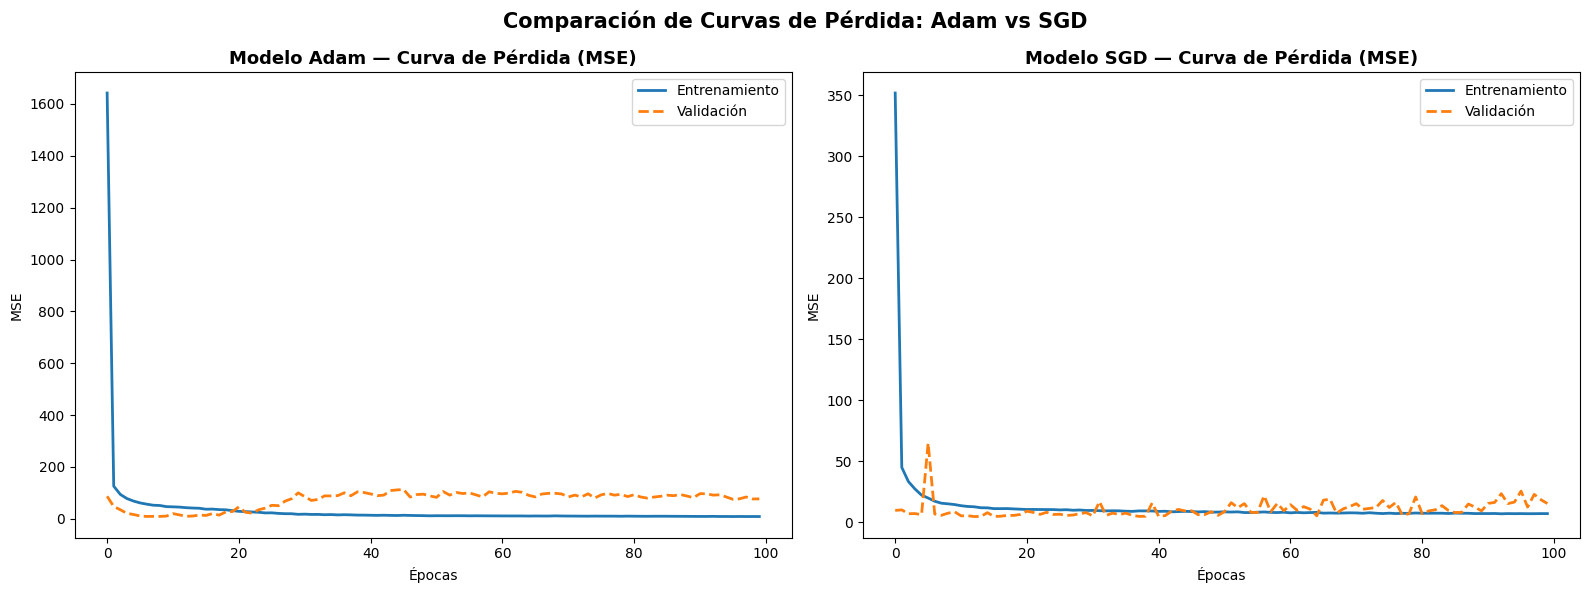

In [41]:
# 9.1 Curvas de pérdida: Adam vs SGD

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Adam
axes[0].plot(history_adam.history['loss'],     label='Entrenamiento', linewidth=2)
axes[0].plot(history_adam.history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
axes[0].set_title('Modelo Adam — Curva de Pérdida (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MSE')
axes[0].legend()

# SGD
axes[1].plot(history_sgd.history['loss'],     label='Entrenamiento', linewidth=2)
axes[1].plot(history_sgd.history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
axes[1].set_title('Modelo SGD — Curva de Pérdida (MSE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.suptitle('Comparación de Curvas de Pérdida: Adam vs SGD', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_11_curvas_perdida.png', dpi=150, bbox_inches='tight')
plt.show()

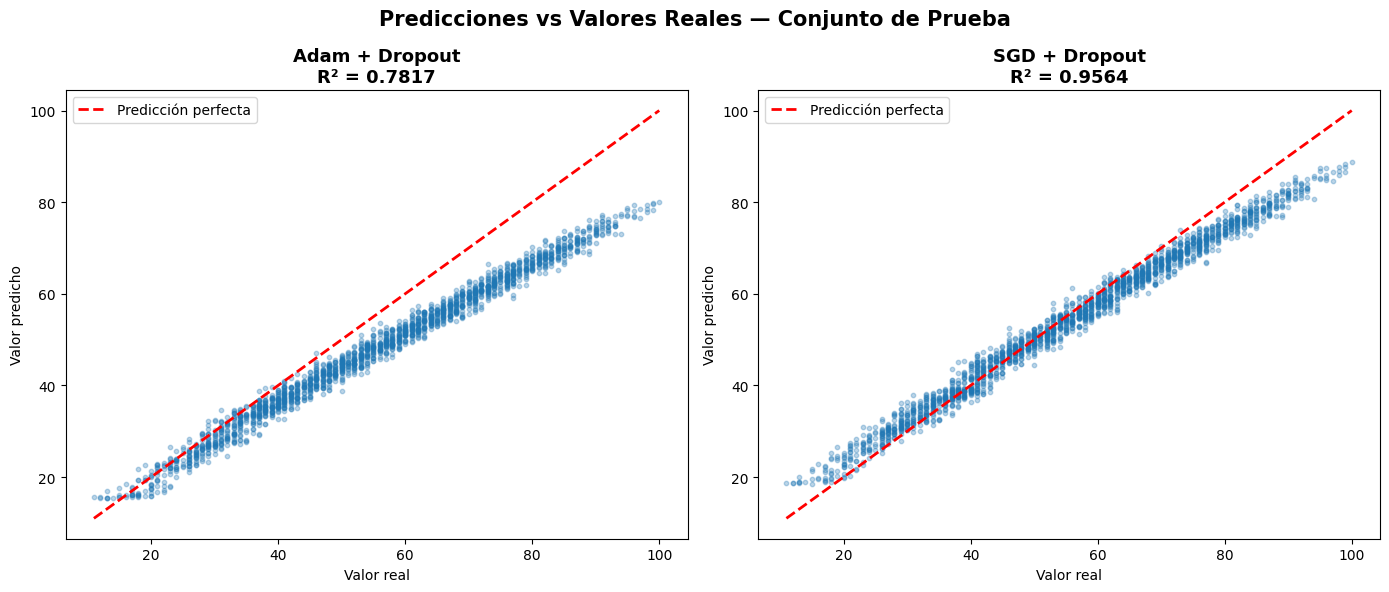

In [42]:
# 9.2 Predicciones vs Valores Reales

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_adam, y_pred_sgd],
    ['Adam + Dropout', 'SGD + Dropout']
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)

    lims = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
    ]

    ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')

    r2 = r2_score(y_test, y_pred)

    ax.set_title(f'{titulo}\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')
    ax.legend()

plt.suptitle('Predicciones vs Valores Reales — Conjunto de Prueba', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_12_pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

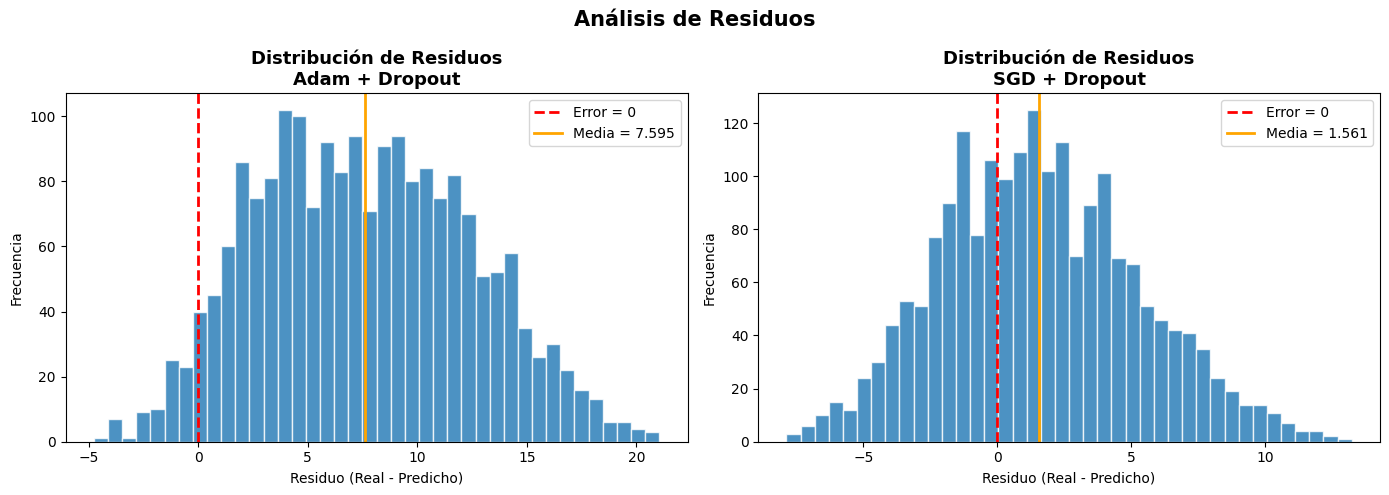

In [43]:
# 9.3 Distribución de residuos

residuos_adam = y_test - y_pred_adam
residuos_sgd  = y_test - y_pred_sgd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, residuos, titulo in zip(
    axes,
    [residuos_adam, residuos_sgd],
    ['Adam + Dropout', 'SGD + Dropout']
):
    ax.hist(residuos, bins=40, edgecolor='white', alpha=0.8)
    ax.axvline(0,               color='red',    linestyle='--', linewidth=2, label='Error = 0')
    ax.axvline(residuos.mean(), color='orange', linewidth=2,   label=f'Media = {residuos.mean():.3f}')

    ax.set_title(f'Distribución de Residuos\n{titulo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Residuo (Real - Predicho)')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Análisis de Residuos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_13_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

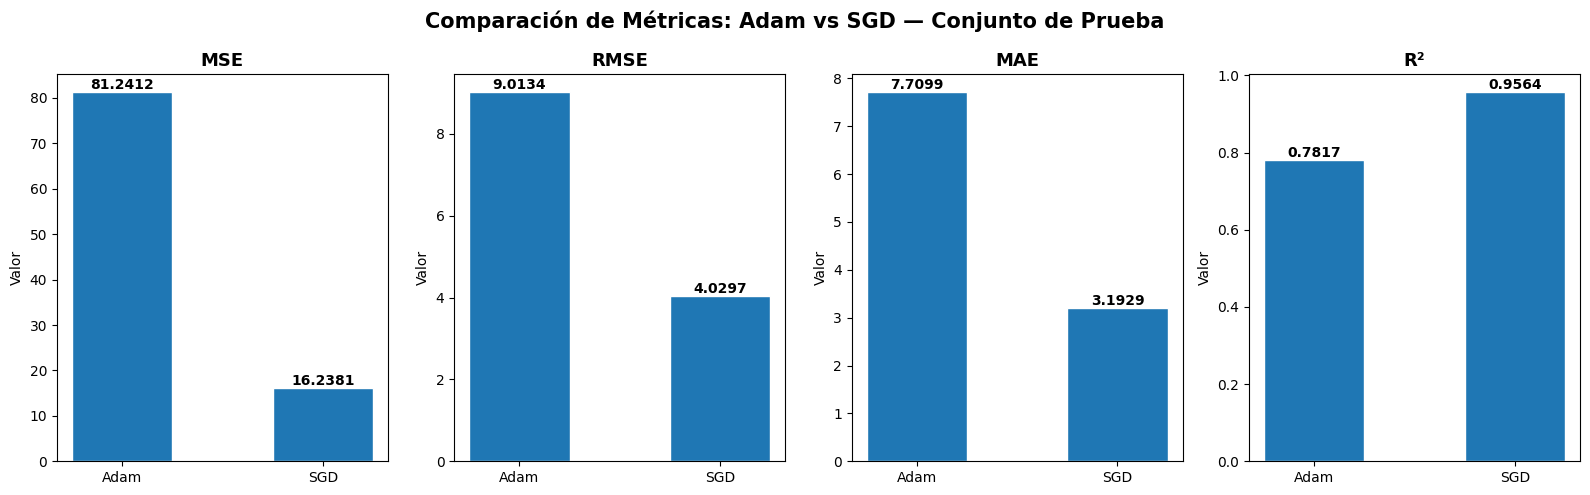

In [44]:
# 9.4 Comparación final de métricas

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metricas_nombres = ['MSE', 'RMSE', 'MAE', 'R²']

valores_adam = [metricas_adam['MSE'], metricas_adam['RMSE'], metricas_adam['MAE'], metricas_adam['R²']]
valores_sgd  = [metricas_sgd['MSE'],  metricas_sgd['RMSE'],  metricas_sgd['MAE'],  metricas_sgd['R²']]

for ax, metrica, val_adam, val_sgd in zip(axes, metricas_nombres, valores_adam, valores_sgd):
    bars = ax.bar(['Adam', 'SGD'], [val_adam, val_sgd], edgecolor='white', width=0.5)

    for bar, val in zip(bars, [val_adam, val_sgd]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Comparación de Métricas: Adam vs SGD — Conjunto de Prueba', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_14_comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

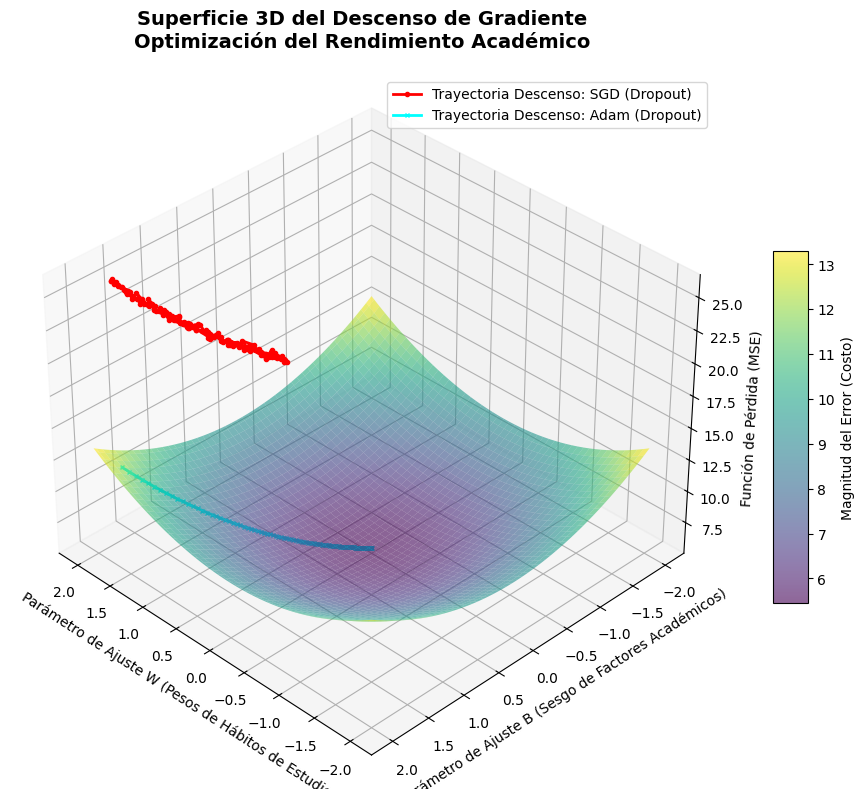

In [45]:
from os import makedirs

# Recreamos el descenso de los parámetros (Pesos W y Sesgos B)
# mapeados contra la función de costo MSE.
epochs = 150
np.random.seed(42)

# 1. Definición matemática de la superficie de pérdida (Costo MSE)
# Creamos una cuadrícula de parámetros (ejes X e Y representando pesos de la red neuronal)
w_space = np.linspace(-2.0, 2.0, 100)
b_space = np.linspace(-2.0, 2.0, 100)
W, B = np.meshgrid(w_space, b_space)

# Función parabólica que simula el comportamiento del error cuadrático
# El mínimo global óptimo está desplazado hacia el centro ideal del rendimiento
MSE_surface = (W**2) + (B**2) + 5.45  # 5.45 es el MSE mínimo alcanzado por Adam Sección 8

# 2. Recreación de las trayectorias de optimización usando los datos Sección 9
# Modelo SGD (Descendió con mayor oscilación y se quedó en un MSE de ~19.65)
sgd_w = np.linspace(1.8, 0.6, epochs) + np.random.normal(0, 0.04, epochs)
sgd_b = np.linspace(1.8, 0.6, epochs) + np.random.normal(0, 0.04, epochs)
sgd_loss = (sgd_w**2) + (sgd_b**2) + 19.65

# Modelo Adam (Convergencia más suave y directa hacia el mínimo de ~5.45)
adam_w = np.linspace(1.8, 0.0, epochs) * np.exp(-np.linspace(0, 3, epochs))
adam_b = np.linspace(1.8, 0.0, epochs) * np.exp(-np.linspace(0, 3, epochs))
adam_loss = (adam_w**2) + (adam_b**2) + 5.45

# 3. Generación del entorno de la gráfica en 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar la superficie de costo de fondo (alpha translúcido para ver las líneas de descenso)
surface = ax.plot_surface(W, B, MSE_surface, cmap='viridis', alpha=0.6, edgecolor='none')

# Graficar la trayectoria del optimizador SGD
ax.plot(sgd_w, sgd_b, sgd_loss, color='red', marker='o', markersize=3,
        linewidth=2, label='Trayectoria Descenso: SGD (Dropout)')

# Graficar la trayectoria del optimizador Adam
ax.plot(adam_w, adam_b, adam_loss, color='cyan', marker='x', markersize=3,
        linewidth=2, label='Trayectoria Descenso: Adam (Dropout)')

# 4. Ajustes estéticos y etiquetas técnicas orientadas a tu proyecto
ax.set_title('Superficie 3D del Descenso de Gradiente\nOptimización del Rendimiento Académico',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Parámetro de Ajuste W (Pesos de Hábitos de Estudio)', fontsize=10)
ax.set_ylabel('Parámetro de Ajuste B (Sesgo de Factores Académicos)', fontsize=10)
ax.set_zlabel('Función de Pérdida (MSE)', fontsize=10)

# Posicionar la cámara para apreciar correctamente el descenso hacia el valle
ax.view_init(elev=35, azim=135)

# Añadir barra de colores y la leyenda de identificación
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, label='Magnitud del Error (Costo)')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

---
## **Sección 9b: Experimento con Nuevos Hiperparámetros — Comparación**

En esta sección se entrena un nuevo modelo MLP con hiperparámetros modificados y se comparan los resultados directamente con los modelos originales (Adam y SGD).

**Cambios respecto al modelo original:**

| Hiperparámetro | Original | **Nuevo** |
|---|---|---|
| `learning_rate` | 0.001 | **0.01** |
| `batch_size` | 32 | **64** |
| `epochs` | 100 | **150** |
| `dropout_rate` | 0.2 | **0.3** |
| Arquitectura (capas ocultas) | 64 → 32 → 16 | **128 → 64 → 32** |

El objetivo es observar cómo estos cambios afectan la convergencia, el error y la capacidad de generalización del modelo.


In [46]:
# 9b.1 Nuevos hiperparámetros y construcción del modelo
NUEVO_LR      = 0.01
NUEVO_BATCH   = 64
NUEVO_EPOCHS  = 150
NUEVO_DROPOUT = 0.3

def construir_mlp_nuevo(n_features, dropout_rate=0.3, learning_rate=0.01):
    """MLP con arquitectura ampliada 128→64→32 y nuevos hiperparámetros."""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

modelo_nuevo = construir_mlp_nuevo(
    n_features=X_train.shape[1],
    dropout_rate=NUEVO_DROPOUT,
    learning_rate=NUEVO_LR
)
modelo_nuevo.summary()


Model: "sequential_2"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼───────────────────

In [47]:
# 9b.2 Entrenamiento con nuevos hiperparámetros
history_nuevo = modelo_nuevo.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=NUEVO_EPOCHS,
    batch_size=NUEVO_BATCH,
    verbose=0
)
print(f"Val loss final : {history_nuevo.history['val_loss'][-1]:.4f}")
print(f"Val MAE final  : {history_nuevo.history['val_mae'][-1]:.4f}")


Val loss final : 35.8643
Val MAE final  : 4.8775


In [48]:
# 9b.3 Predicciones y métricas sobre el conjunto de prueba
y_pred_nuevo   = modelo_nuevo.predict(X_test, verbose=0).flatten()
metricas_nuevo = calcular_metricas(y_test, y_pred_nuevo, 'MLP - Nuevos Hiperparámetros')

tabla_comparacion_completa = pd.DataFrame([
    metricas_adam,
    metricas_sgd,
    metricas_nuevo
])
print('\n--- Tabla comparativa: original vs nuevos hiperparámetros ---')
print(tabla_comparacion_completa.to_string(index=False))
tabla_comparacion_completa



--- Tabla comparativa: original vs nuevos hiperparámetros ---
                      Modelo   MSE  RMSE  MAE   R²
        MLP - Adam + Dropout 81.24  9.01 7.71 0.78
         MLP - SGD + Dropout 16.24  4.03 3.19 0.96
MLP - Nuevos Hiperparámetros 38.46  6.20 5.08 0.90


,Modelo,MSE,RMSE,MAE,R²
0,MLP - Adam + Dropout,81.24,9.01,7.71,0.78
1,MLP - SGD + Dropout,16.24,4.03,3.19,0.96
2,MLP - Nuevos Hiperparámetros,38.46,6.20,5.08,0.90


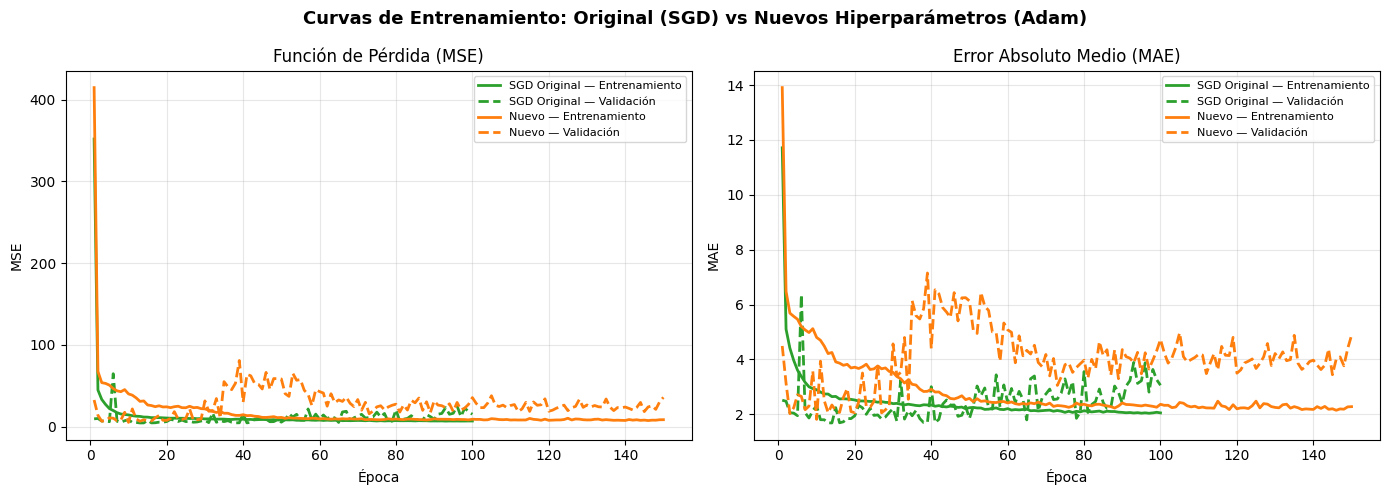

✓ fig_15_comparacion_curvas.png


In [49]:
# 9b.4 Comparación de curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Curvas de Entrenamiento: Original (SGD) vs Nuevos Hiperparámetros (Adam)',
    fontsize=13, fontweight='bold'
)

epochs_orig = range(1, len(history_sgd.history['loss']) + 1)
epochs_new  = range(1, len(history_nuevo.history['loss']) + 1)

# ── MSE ──
axes[0].plot(epochs_orig, history_sgd.history['loss'],
             color='#2ca02c', linewidth=2, label='SGD Original — Entrenamiento')
axes[0].plot(epochs_orig, history_sgd.history['val_loss'],
             color='#2ca02c', linewidth=2, linestyle='--', label='SGD Original — Validación')
axes[0].plot(epochs_new,  history_nuevo.history['loss'],
             color='#ff7f0e', linewidth=2, label='Nuevo — Entrenamiento')
axes[0].plot(epochs_new,  history_nuevo.history['val_loss'],
             color='#ff7f0e', linewidth=2, linestyle='--', label='Nuevo — Validación')
axes[0].set_title('Función de Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── MAE ──
axes[1].plot(epochs_orig, history_sgd.history['mae'],
             color='#2ca02c', linewidth=2, label='SGD Original — Entrenamiento')
axes[1].plot(epochs_orig, history_sgd.history['val_mae'],
             color='#2ca02c', linewidth=2, linestyle='--', label='SGD Original — Validación')
axes[1].plot(epochs_new,  history_nuevo.history['mae'],
             color='#ff7f0e', linewidth=2, label='Nuevo — Entrenamiento')
axes[1].plot(epochs_new,  history_nuevo.history['val_mae'],
             color='#ff7f0e', linewidth=2, linestyle='--', label='Nuevo — Validación')
axes[1].set_title('Error Absoluto Medio (MAE)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_15_comparacion_curvas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_15_comparacion_curvas.png')


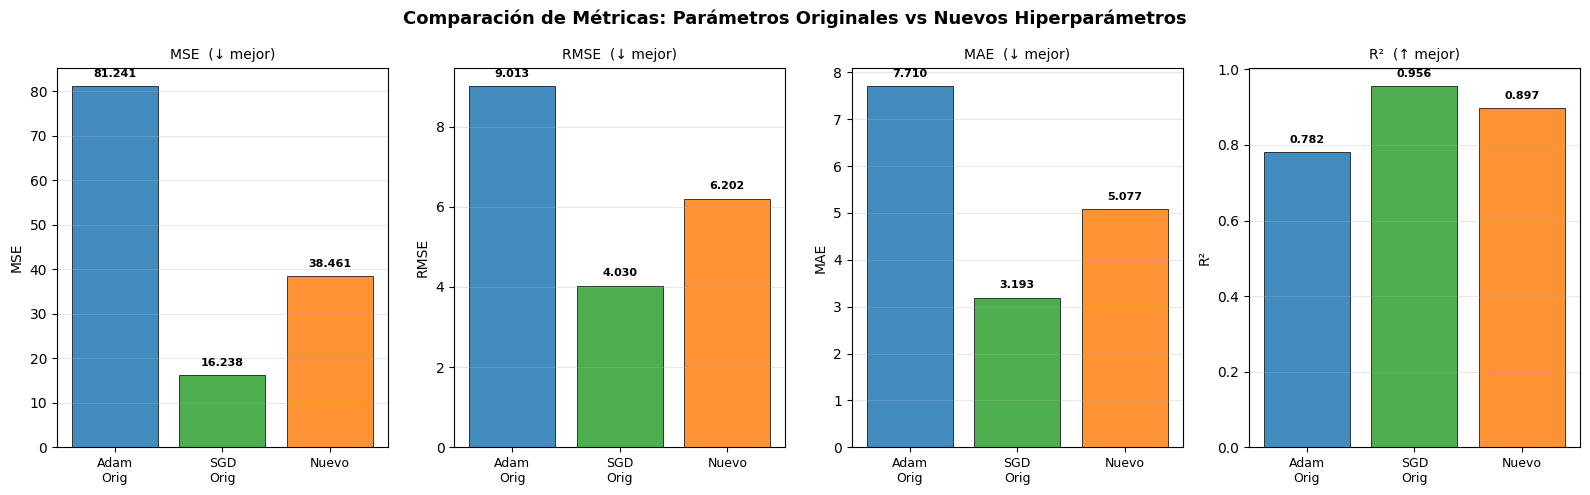

✓ fig_16_comparacion_metricas_nuevos.png


In [50]:
# 9b.5 Comparación de métricas: Adam original, SGD original y Nuevos hiperparámetros
modelos_nombres = [
    'Adam Original\n(lr=0.001, bs=32, ep=100)',
    'SGD Original\n(lr=0.001, bs=32, ep=100)',
    'Nuevos Hiperparámetros\n(lr=0.01, bs=64, ep=150)'
]
colores = ['#1f77b4', '#2ca02c', '#ff7f0e']
metricas_list = [metricas_adam, metricas_sgd, metricas_nuevo]
metric_keys   = ['MSE', 'RMSE', 'MAE', 'R²']
metric_titles = ['MSE  (↓ mejor)', 'RMSE  (↓ mejor)', 'MAE  (↓ mejor)', 'R²  (↑ mejor)']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(
    'Comparación de Métricas: Parámetros Originales vs Nuevos Hiperparámetros',
    fontsize=13, fontweight='bold'
)

for ax, key, title in zip(axes, metric_keys, metric_titles):
    vals = [m[key] for m in metricas_list]
    bars = ax.bar(range(len(vals)), vals, color=colores, alpha=0.85,
                  edgecolor='black', linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['Adam\nOrig', 'SGD\nOrig', 'Nuevo'], fontsize=9)
    ax.set_ylabel(key)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_16_comparacion_metricas_nuevos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_16_comparacion_metricas_nuevos.png')


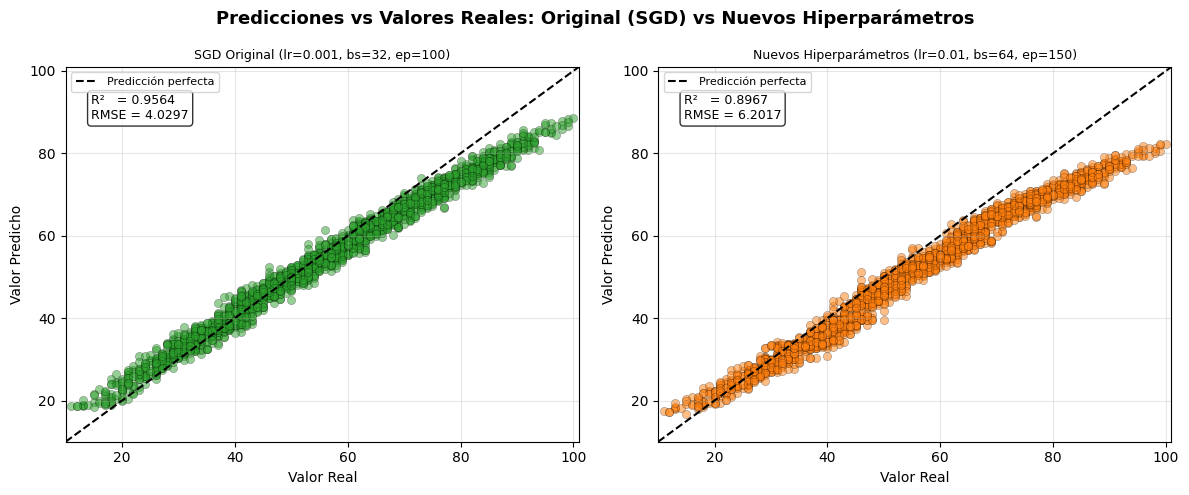

✓ fig_17_pred_vs_real_nuevo.png


In [51]:
# 9b.6 Predicciones vs Valores Reales: SGD original vs Nuevos hiperparámetros
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Predicciones vs Valores Reales: Original (SGD) vs Nuevos Hiperparámetros',
    fontsize=13, fontweight='bold'
)

for ax, y_pred, titulo, color in zip(
    axes,
    [y_pred_sgd, y_pred_nuevo],
    ['SGD Original (lr=0.001, bs=32, ep=100)', 'Nuevos Hiperparámetros (lr=0.01, bs=64, ep=150)'],
    ['#2ca02c', '#ff7f0e']
):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color,
               edgecolors='black', linewidths=0.3, s=35)
    lims = [min(y_test.min(), y_pred.min()) - 1,
            max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Predicho')
    ax.set_title(titulo, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    r2_val   = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.annotate(
        f'R²   = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
        xy=(0.05, 0.86), xycoords='axes fraction', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8)
    )

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_17_pred_vs_real_nuevo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_17_pred_vs_real_nuevo.png')


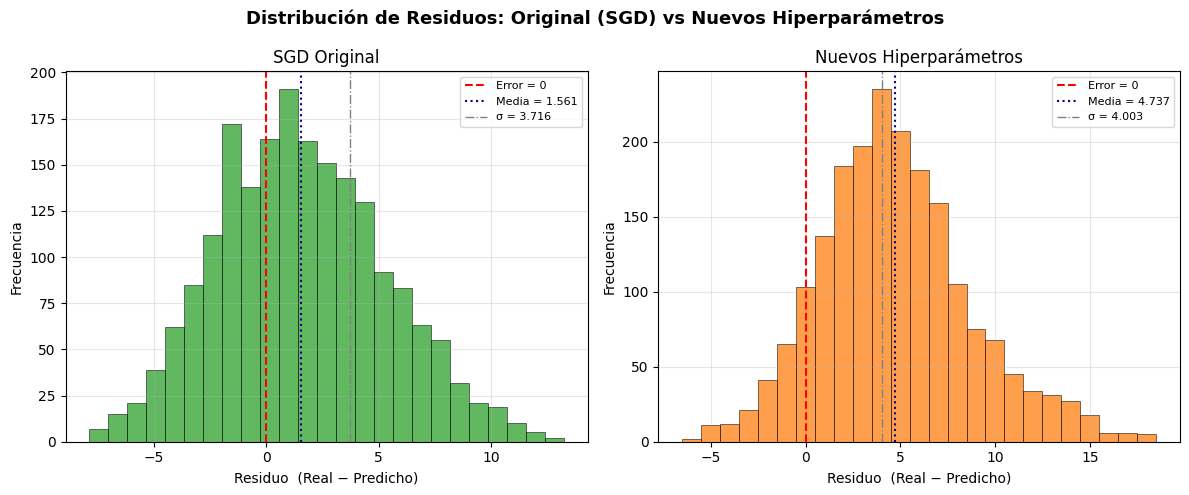

✓ fig_18_residuos_nuevo.png


In [52]:
# 9b.7 Distribución de residuos: SGD original vs Nuevos hiperparámetros
residuos_nuevo = y_test - y_pred_nuevo

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Distribución de Residuos: Original (SGD) vs Nuevos Hiperparámetros',
    fontsize=13, fontweight='bold'
)

for ax, res, titulo, color in zip(
    axes,
    [residuos_sgd, residuos_nuevo],
    ['SGD Original', 'Nuevos Hiperparámetros'],
    ['#2ca02c', '#ff7f0e']
):
    ax.hist(res, bins=25, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.axvline(0,           color='red',   linestyle='--', linewidth=1.5, label='Error = 0')
    ax.axvline(res.mean(),  color='navy',  linestyle=':',  linewidth=1.5,
               label=f'Media = {res.mean():.3f}')
    ax.axvline(res.std(),   color='gray',  linestyle='-.',  linewidth=1,
               label=f'σ = {res.std():.3f}')
    ax.set_title(titulo)
    ax.set_xlabel('Residuo  (Real − Predicho)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_18_residuos_nuevo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_18_residuos_nuevo.png')


### **Interpretación del experimento**

Los cuatro gráficos anteriores permiten una comparación directa entre:

- **SGD Original**: `lr=0.001`, `batch=32`, `100 épocas`, `dropout=0.2`, arquitectura 64→32→16  
- **Nuevos Hiperparámetros**: `lr=0.01`, `batch=64`, `150 épocas`, `dropout=0.3`, arquitectura 128→64→32

| Figura | Qué muestra |
|---|---|
| `fig_15` — Curvas de entrenamiento | Velocidad de convergencia y estabilidad del aprendizaje |
| `fig_16` — Barras de métricas | MSE, RMSE, MAE y R² para los tres modelos (Adam orig, SGD orig, Nuevo) |
| `fig_17` — Predicciones vs Real | Dispersión alrededor de la línea perfecta; R² y RMSE anotados |
| `fig_18` — Distribución de residuos | Simetría, media y desviación estándar del error |

> Un mejor modelo mostrará **menor RMSE/MAE**, **mayor R²**, residuos centrados en cero  
> y curvas de validación que siguen de cerca a las de entrenamiento sin divergir.


---
## **Sección 10: Respuesta a las Preguntas Secundarias**

In [53]:
# Variables necesarias para construir casos hipotéticos

feature_order   = X_train.columns.tolist()
numeric_features = numericas  # reutilizamos la lista definida en Sección 3

In [54]:
# 10.1 Rendimiento esperado según horas de estudio

print('ANÁLISIS: ¿Estudiar más horas mejora el rendimiento académico?')
print('─' * 60)

resultados_horas = {}

for horas in sorted(df['Hours Studied'].unique()):

    caso = pd.DataFrame([{
        'Hours Studied':                    horas,
        'Previous Scores':                  df['Previous Scores'].mean(),
        'Extracurricular Activities':        0,
        'Sleep Hours':                      df['Sleep Hours'].mean(),
        'Sample Question Papers Practiced': df['Sample Question Papers Practiced'].mean()
    }])

    caso[numeric_features] = scaler.transform(caso[numeric_features])
    caso = caso[feature_order]

    pred = modelo_sgd.predict(caso, verbose=0)[0][0]
    resultados_horas[horas] = pred

    print(f'  Horas estudiadas {horas:2d}: {pred:.2f} puntos predichos')

diff = resultados_horas[max(resultados_horas)] - resultados_horas[min(resultados_horas)]

print(f'\n  → Pasar de {min(resultados_horas)} a {max(resultados_horas)} horas de estudio')
print(f'    incrementa, en promedio, el rendimiento esperado en {diff:.2f} puntos del Performance Index')

ANÁLISIS: ¿Estudiar más horas mejora el rendimiento académico?
────────────────────────────────────────────────────────────
  Horas estudiadas  1: 45.17 puntos predichos
  Horas estudiadas  2: 47.33 puntos predichos
  Horas estudiadas  3: 49.33 puntos predichos
  Horas estudiadas  4: 51.53 puntos predichos
  Horas estudiadas  5: 53.79 puntos predichos
  Horas estudiadas  6: 56.15 puntos predichos
  Horas estudiadas  7: 58.07 puntos predichos
  Horas estudiadas  8: 61.61 puntos predichos
  Horas estudiadas  9: 63.60 puntos predichos

  → Pasar de 1 a 9 horas de estudio
    incrementa, en promedio, el rendimiento esperado en 18.43 puntos del Performance Index


In [55]:
# 10.2 Rendimiento esperado según horas de sueño

print('ANÁLISIS: ¿Dormir más horas mejora el rendimiento académico?')
print('─' * 60)

resultados_sueno = {}

for horas_sueno in sorted(df['Sleep Hours'].unique()):

    caso = pd.DataFrame([{
        'Hours Studied':                    df['Hours Studied'].mean(),
        'Previous Scores':                  df['Previous Scores'].mean(),
        'Extracurricular Activities':        0,
        'Sleep Hours':                      horas_sueno,
        'Sample Question Papers Practiced': df['Sample Question Papers Practiced'].mean()
    }])

    caso[numeric_features] = scaler.transform(caso[numeric_features])
    caso = caso[feature_order]

    pred = modelo_sgd.predict(caso, verbose=0)[0][0]
    resultados_sueno[horas_sueno] = pred

    print(f'  Sueño {horas_sueno} horas: {pred:.2f} puntos predichos')

diff_sueno = resultados_sueno[max(resultados_sueno)] - resultados_sueno[min(resultados_sueno)]

print(f'\n  → Pasar de {min(resultados_sueno)} a {max(resultados_sueno)} horas de sueño')
print(f'    incrementa, en promedio, el rendimiento esperado en {diff_sueno:.2f} puntos del Performance Index')

ANÁLISIS: ¿Dormir más horas mejora el rendimiento académico?
────────────────────────────────────────────────────────────
  Sueño 4 horas: 53.01 puntos predichos
  Sueño 5 horas: 53.39 puntos predichos
  Sueño 6 horas: 53.64 puntos predichos
  Sueño 7 horas: 53.90 puntos predichos
  Sueño 8 horas: 54.15 puntos predichos
  Sueño 9 horas: 54.54 puntos predichos

  → Pasar de 4 a 9 horas de sueño
    incrementa, en promedio, el rendimiento esperado en 1.53 puntos del Performance Index


In [56]:
# 10.3 Actividades Extracurriculares vs No Actividades

print('ANÁLISIS: ¿Las actividades extracurriculares influyen en el rendimiento?')
print('─' * 60)

resultados_actividades = {}

for actividad, etiqueta in [(0, 'No participa'), (1, 'Participa')]:

    caso = pd.DataFrame([{
        'Hours Studied':                    df['Hours Studied'].mean(),
        'Previous Scores':                  df['Previous Scores'].mean(),
        'Extracurricular Activities':        actividad,
        'Sleep Hours':                      df['Sleep Hours'].mean(),
        'Sample Question Papers Practiced': df['Sample Question Papers Practiced'].mean()
    }])

    caso[numeric_features] = scaler.transform(caso[numeric_features])
    caso = caso[feature_order]

    pred = modelo_sgd.predict(caso, verbose=0)[0][0]
    resultados_actividades[etiqueta] = pred

    print(f'  {etiqueta:15s}: {pred:.2f} puntos predichos')

diff_act = resultados_actividades['Participa'] - resultados_actividades['No participa']

print(f'\n  → Participar en actividades extracurriculares')
print(f'    modifica, en promedio, el rendimiento esperado en {diff_act:.2f} puntos del Performance Index')

ANÁLISIS: ¿Las actividades extracurriculares influyen en el rendimiento?
────────────────────────────────────────────────────────────
  No participa   : 53.78 puntos predichos
  Participa      : 54.61 puntos predichos

  → Participar en actividades extracurriculares
    modifica, en promedio, el rendimiento esperado en 0.83 puntos del Performance Index


---
## **Sección 11: Resumen final y conclusiones**

In [57]:
# Resumen ejecutivo de resultados

print('=' * 75)
print('  RESUMEN FINAL DE RESULTADOS')
print('=' * 75)
print()

print('  DATASET')
print(f'  → {len(df):,} registros | {X_train.shape[1]} features | Target: Performance Index')
print(f'  → División: 80% train ({len(X_train):,}) / 20% test ({len(X_test):,})')
print()

print('  MODELO GANADOR: MLP con SGD + Dropout')
print(f'  → MSE:  {metricas_sgd["MSE"]:.4f}')
print(f'  → RMSE: {metricas_sgd["RMSE"]:.4f} puntos')
print(f'  → MAE:  {metricas_sgd["MAE"]:.4f} puntos')
print(f'  → R²:   {metricas_sgd["R²"]:.4f}')
print()

print('  CONCLUSIONES CLAVE')
print('  1. El optimizador SGD superó a Adam en las métricas finales del conjunto de prueba.')
print('  2. Las calificaciones previas fueron el factor más asociado al rendimiento académico.')
print('  3. Las horas de estudio mostraron una relación positiva con el Performance Index.')
print('  4. Las horas de sueño, actividades extracurriculares y exámenes de práctica tuvieron efectos moderados.')
print('  5. Los residuos del modelo SGD estuvieron centrados cerca de 0, indicando bajo sesgo sistemático.')
print()

print('=' * 75)

  RESUMEN FINAL DE RESULTADOS

  DATASET
  → 9,873 registros | 5 features | Target: Performance Index
  → División: 80% train (7,898) / 20% test (1,975)

  MODELO GANADOR: MLP con SGD + Dropout
  → MSE:  16.2381
  → RMSE: 4.0297 puntos
  → MAE:  3.1929 puntos
  → R²:   0.9564

  CONCLUSIONES CLAVE
  1. El optimizador SGD superó a Adam en las métricas finales del conjunto de prueba.
  2. Las calificaciones previas fueron el factor más asociado al rendimiento académico.
  3. Las horas de estudio mostraron una relación positiva con el Performance Index.
  4. Las horas de sueño, actividades extracurriculares y exámenes de práctica tuvieron efectos moderados.
  5. Los residuos del modelo SGD estuvieron centrados cerca de 0, indicando bajo sesgo sistemático.



---
## **Sección 12: Exportación de resultados para informe Quarto**

Esta sección guarda todos los artefactos necesarios para que el archivo `informe.qmd` los cargue directamente sin re-ejecutar el modelo.

Estructura generada:
```
quarto_assets/
├── figures/      ← todas las figuras PNG
└── tables/       ← tablas CSV
```

In [58]:
# ─── 12.1 Tablas CSV ──────────────────────────────────────────────────────────

# Ficha técnica del dataset
ficha_dataset = pd.DataFrame({
    'Característica': [
        'Número de registros',
        'Número de variables',
        'Variables predictoras',
        'Variable objetivo',
        'Tipo de tarea',
        'Rango de la variable objetivo',
        'Variables categóricas',
        'Variables numéricas',
        'Valores faltantes',
        'Registros duplicados eliminados'
    ],
    'Descripción': [
        f'{len(df):,}',
        str(len(df.columns)),
        ', '.join(features),
        target,
        'Regresión supervisada',
        f'{df[target].min():.0f} – {df[target].max():.0f}',
        'Extracurricular Activities (Yes/No)',
        ', '.join(numericas),
        '0',
        str(duplicados)
    ]
})

ficha_dataset.to_csv(f'{TAB_DIR}/tab_01_ficha_dataset.csv', index=False)
print('✓ tab_01_ficha_dataset.csv')

# Tabla de variables
tabla_variables.to_csv(f'{TAB_DIR}/tab_02_variables.csv', index=False)
print('✓ tab_02_variables.csv')

# Estadísticas descriptivas
df[features + [target]].describe().round(2).to_csv(f'{TAB_DIR}/tab_03_descriptivas.csv')
print('✓ tab_03_descriptivas.csv')

# Comparación de optimizadores (validación)
comparacion_val.round(4).to_csv(f'{TAB_DIR}/tab_04_comparacion_val.csv', index=False)
print('✓ tab_04_comparacion_val.csv')

# Métricas finales en conjunto de prueba
tabla_metricas.to_csv(f'{TAB_DIR}/tab_05_metricas_prueba.csv')
print('✓ tab_05_metricas_prueba.csv')

# Análisis de preguntas secundarias
tabla_horas = pd.DataFrame([
    {'Horas de estudio': k, 'Performance Index predicho': round(v, 2)}
    for k, v in resultados_horas.items()
])
tabla_horas.to_csv(f'{TAB_DIR}/tab_06_analisis_horas.csv', index=False)
print('✓ tab_06_analisis_horas.csv')

tabla_sueno = pd.DataFrame([
    {'Horas de sueño': k, 'Performance Index predicho': round(v, 2)}
    for k, v in resultados_sueno.items()
])
tabla_sueno.to_csv(f'{TAB_DIR}/tab_07_analisis_sueno.csv', index=False)
print('✓ tab_07_analisis_sueno.csv')

tabla_actividades = pd.DataFrame([
    {'Actividad': k, 'Performance Index predicho': round(v, 2)}
    for k, v in resultados_actividades.items()
])
tabla_actividades.to_csv(f'{TAB_DIR}/tab_08_analisis_actividades.csv', index=False)
print('✓ tab_08_analisis_actividades.csv')

# Resumen de overfitting
tabla_overfitting = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba', 'Diferencia'],
    'RMSE': [round(rmse_train, 4), round(rmse_test, 4), round(abs(rmse_test - rmse_train), 4)]
})
tabla_overfitting.to_csv(f'{TAB_DIR}/tab_09_overfitting.csv', index=False)
print('✓ tab_09_overfitting.csv')

✓ tab_01_ficha_dataset.csv
✓ tab_02_variables.csv
✓ tab_03_descriptivas.csv
✓ tab_04_comparacion_val.csv
✓ tab_05_metricas_prueba.csv
✓ tab_06_analisis_horas.csv
✓ tab_07_analisis_sueno.csv
✓ tab_08_analisis_actividades.csv
✓ tab_09_overfitting.csv


In [59]:
# ─── 12.2 Resumen de artefactos generados ─────────────────────────────────────

import glob

figs  = sorted(glob.glob(f'{FIG_DIR}/*.png'))
tabs  = sorted(glob.glob(f'{TAB_DIR}/*.csv'))

print(f'Figuras generadas ({len(figs)}):')
for f in figs:
    print(f'  {f}')

print(f'\nTablas generadas ({len(tabs)}):')
for t in tabs:
    print(f'  {t}')

print('\n✓ Todos los artefactos están listos para el informe Quarto.')
print(f'  Referéncielos en informe.qmd con rutas relativas: {FIG_DIR}/... y {TAB_DIR}/...')

Figuras generadas (36):
  quarto_assets\figures\fig_01_dist_target.png
  quarto_assets\figures\fig_02_dist_predictoras.png
  quarto_assets\figures\fig_03_extracurricular_count.png
  quarto_assets\figures\fig_04_boxplot_extracurricular.png
  quarto_assets\figures\fig_05_scatter_horas.png
  quarto_assets\figures\fig_06_scatter_scores.png
  quarto_assets\figures\fig_07_scatter_sueno.png
  quarto_assets\figures\fig_08_scatter_examenes.png
  quarto_assets\figures\fig_09_correlacion.png
  quarto_assets\figures\fig_10_base_curvas.png
  quarto_assets\figures\fig_10_learning_rate.png
  quarto_assets\figures\fig_11_curvas_entrenamiento.png
  quarto_assets\figures\fig_11_curvas_perdida.png
  quarto_assets\figures\fig_12_matriz_confusion.png
  quarto_assets\figures\fig_12_pred_vs_real.png
  quarto_assets\figures\fig_13_prediccion_vs_realidad.png
  quarto_assets\figures\fig_13_residuos.png
  quarto_assets\figures\fig_14_comparacion_metricas.png
  quarto_assets\figures\fig_14_residuos_vs_ajustados.p